In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    accuracy_score
)

from xgboost import XGBClassifier

In [2]:
df = pd.read_excel("C:/Users/ankur/Downloads/FastagFraudDetection_Cleaned_With_Location.xlsx")

In [3]:
print(df.shape)
print(df.head())
print(df.columns.tolist())

(5000, 21)
   Transaction_ID Timestamp Vehicle_Type         FastagID TollBoothID  \
0               1       NaT          Bus  FTG-001-ABC-121       A-101   
1               2       NaT          Car  FTG-002-XYZ-451       B-102   
2               3       NaT   Motorcycle              NaN       D-104   
3               4       NaT        Truck  FTG-044-LMN-322       C-103   
4               5       NaT          Van  FTG-505-DEF-652       B-102   

  Lane_Type Vehicle_Dimensions  Transaction_Amount  Amount_paid  \
0   Express              Large                 350          120   
1   Regular              Small                 120          100   
2   Regular              Small                   0            0   
3   Regular              Large                 350          120   
4   Express             Medium                 140          100   

                   Geographical_Location  ...  Vehicle_Plate_Number  \
0  13.059816123454882, 77.77068662374292  ...            KA11AB1234   
1  13

In [4]:
#Create the fraud target

df["Fraud_Label"] = (
    df["Fraud_indicator"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("fraud")
    .astype(int)
)

In [5]:
print(df["Fraud_Label"].value_counts())
print(df["Fraud_Label"].value_counts(normalize=True) * 100)

Fraud_Label
0    4017
1     983
Name: count, dtype: int64
Fraud_Label
0    80.34
1    19.66
Name: proportion, dtype: float64


In [6]:
#Select Independent Variables

features = [
    "Vehicle_Type",
    "Vehicle_Dimensions",
    "TollBoothID",
    "Lane_Type",
    "Vehicle_Speed"
]

target = "Fraud_Label"

X = df[features].copy()
y = df[target].copy()

In [7]:
print(X.head())
print(y.head())

  Vehicle_Type Vehicle_Dimensions TollBoothID Lane_Type  Vehicle_Speed
0          Bus              Large       A-101   Express             65
1          Car              Small       B-102   Regular             78
2   Motorcycle              Small       D-104   Regular             53
3        Truck              Large       C-103   Regular             92
4          Van             Medium       B-102   Express             60
0    1
1    1
2    0
3    1
4    1
Name: Fraud_Label, dtype: int64


In [8]:
#Identify categorical and numerical variables

categorical_features = [
    "Vehicle_Type",
    "Vehicle_Dimensions",
    "TollBoothID",
    "Lane_Type"
]

numerical_features = [
    "Vehicle_Speed"
]

In [9]:
print(X.isnull().sum())

Vehicle_Type          0
Vehicle_Dimensions    0
TollBoothID           0
Lane_Type             0
Vehicle_Speed         0
dtype: int64


In [10]:
for col in categorical_features:
    X[col] = X[col].fillna("Unknown")

In [11]:
#Train/Test Split:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
print("Training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting set:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
Fraud_Label
0    80.35
1    19.65
Name: proportion, dtype: float64

Testing set:
Fraud_Label
0    80.3
1    19.7
Name: proportion, dtype: float64


In [13]:
#Encode categorical variables

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [14]:
#Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [15]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

In [16]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [18]:
#XGBoost

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [19]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)
    ]
)

In [20]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
xgb_pred = xgb_pipeline.predict(X_test)

xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [22]:
#Evaluate both models

def evaluate_model(name, y_true, y_pred, y_prob):

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nAccuracy:",
          round(accuracy_score(y_true, y_pred), 4))

    print("Precision:",
          round(precision_score(y_true, y_pred), 4))

    print("Recall:",
          round(recall_score(y_true, y_pred), 4))

    print("F1 Score:",
          round(f1_score(y_true, y_pred), 4))

    print("ROC-AUC:",
          round(roc_auc_score(y_true, y_prob), 4))

    print("PR-AUC:",
          round(average_precision_score(y_true, y_prob), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [23]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

Random Forest

Accuracy: 0.595
Precision: 0.2277
Recall: 0.4416
F1 Score: 0.3005
ROC-AUC: 0.6014
PR-AUC: 0.2618

Confusion Matrix:
[[508 295]
 [110  87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.63      0.71       803
           1       0.23      0.44      0.30       197

    accuracy                           0.59      1000
   macro avg       0.52      0.54      0.51      1000
weighted avg       0.70      0.59      0.63      1000



In [24]:
evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

XGBoost

Accuracy: 0.8
Precision: 0.2857
Recall: 0.0102
F1 Score: 0.0196
ROC-AUC: 0.6053
PR-AUC: 0.2656

Confusion Matrix:
[[798   5]
 [195   2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89       803
           1       0.29      0.01      0.02       197

    accuracy                           0.80      1000
   macro avg       0.54      0.50      0.45      1000
weighted avg       0.70      0.80      0.72      1000



In [25]:
#Stacking Ensemble

from sklearn.ensemble import ExtraTreesClassifier

In [26]:
rf_base = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [27]:
stacking_model = StackingClassifier(
    estimators=[
        ("rf", rf_base),
        ("xgb", xgb_base)
    ],
    final_estimator=ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

In [28]:
stacking_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("stacking", stacking_model)
    ]
)

In [29]:
stacking_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('stacking', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
stack_pred = stacking_pipeline.predict(X_test)

stack_prob = stacking_pipeline.predict_proba(X_test)[:, 1]

In [31]:
evaluate_model(
    "Stacking Ensemble",
    y_test,
    stack_pred,
    stack_prob
)

Stacking Ensemble

Accuracy: 0.721
Precision: 0.2153
Recall: 0.1574
F1 Score: 0.1818
ROC-AUC: 0.5886
PR-AUC: 0.2248

Confusion Matrix:
[[690 113]
 [166  31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       803
           1       0.22      0.16      0.18       197

    accuracy                           0.72      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.69      0.72      0.70      1000



In [32]:
results = []

models = {
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob),
    "Stacking": (stack_pred, stack_prob)
}

for name, (pred, prob) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "PR-AUC",
    ascending=False
)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,XGBoost,0.800,0.2857,0.0102,0.0196,0.6053,0.2656
0,Random Forest,0.595,0.2277,0.4416,0.3005,0.6014,0.2618
2,Stacking,0.721,0.2153,0.1574,0.1818,0.5886,0.2248


In [36]:
for name, pred in [
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred),
    ("Stacking", stack_pred)
]:
    
    print("\n", "="*40)
    print(name)
    print("="*40)
    
    print("Predicted classes:")
    print(pd.Series(pred).value_counts())
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, pred))


Random Forest
Predicted classes:
0    618
1    382
Name: count, dtype: int64

Confusion Matrix:
[[508 295]
 [110  87]]

XGBoost
Predicted classes:
0    993
1      7
Name: count, dtype: int64

Confusion Matrix:
[[798   5]
 [195   2]]

Stacking
Predicted classes:
0    856
1    144
Name: count, dtype: int64

Confusion Matrix:
[[690 113]
 [166  31]]


In [37]:
scale_pos_weight = 4017 / 983

In [38]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=4.09,

    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [39]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [40]:
evaluate_model(
    "XGBoost - Class Balanced",
    y_test,
    xgb_pred,
    xgb_prob
)

XGBoost - Class Balanced

Accuracy: 0.537
Precision: 0.2361
Recall: 0.6041
F1 Score: 0.3395
ROC-AUC: 0.61
PR-AUC: 0.2668

Confusion Matrix:
[[418 385]
 [ 78 119]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.52      0.64       803
           1       0.24      0.60      0.34       197

    accuracy                           0.54      1000
   macro avg       0.54      0.56      0.49      1000
weighted avg       0.72      0.54      0.58      1000



In [41]:
# Get transformed feature names
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get RF importance
importances = rf_pipeline.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
18,numerical__Vehicle_Speed,0.722255
2,categorical__Vehicle_Type_Motorcycle,0.100553
15,categorical__TollBoothID_D-106,0.051087
9,categorical__Vehicle_Dimensions_Small,0.038709
1,categorical__Vehicle_Type_Car,0.014361
10,categorical__TollBoothID_A-101,0.013123
14,categorical__TollBoothID_D-105,0.008095
17,categorical__Lane_Type_Regular,0.007806
11,categorical__TollBoothID_B-102,0.007600
16,categorical__Lane_Type_Express,0.007134


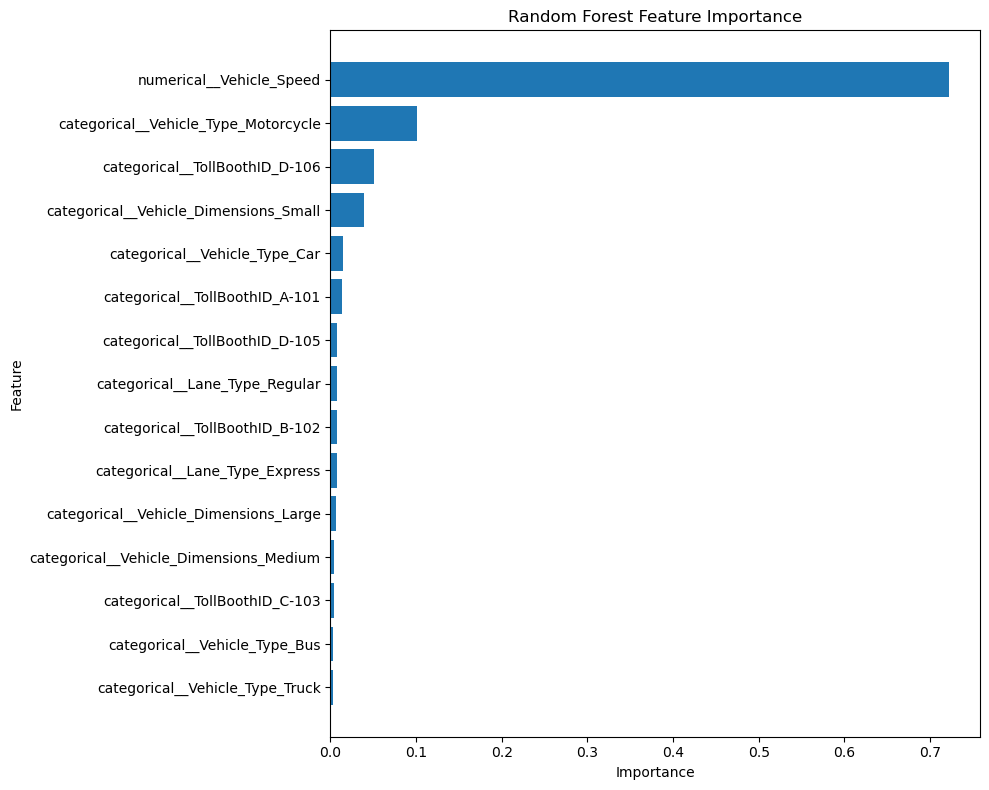

In [44]:
plt.figure(figsize=(10, 8))

top_features = feature_importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [43]:
import matplotlib.pyplot as plt

In [45]:
print(df.groupby("Fraud_Label")["Vehicle_Speed"].describe())

              count       mean        std   min   25%   50%   75%    max
Fraud_Label                                                             
0            4017.0  67.731392  16.539335  10.0  54.0  67.0  82.0  118.0
1             983.0  68.340793  16.832977  20.0  55.0  68.0  82.0  118.0


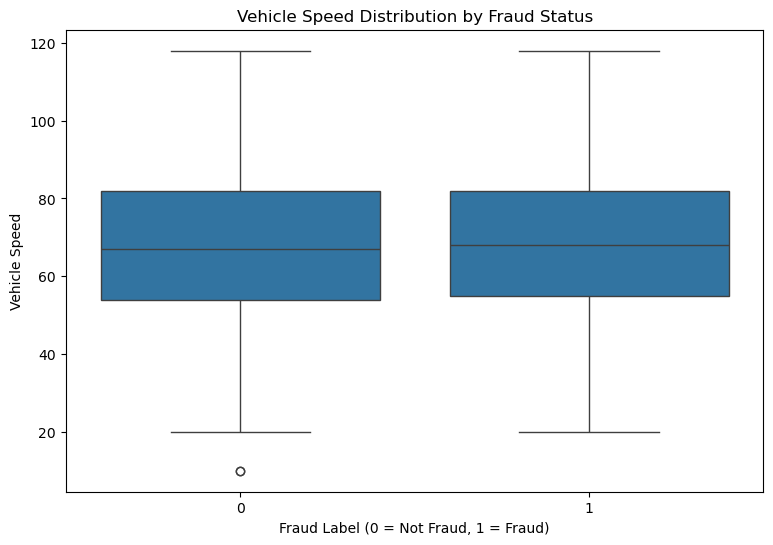

In [48]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Fraud_Label",
    y="Vehicle_Speed"
)

plt.title("Vehicle Speed Distribution by Fraud Status")
plt.xlabel("Fraud Label (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Vehicle Speed")

plt.show()

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
scale_pos_weight = 4.09

In [67]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

display(permutation_df)

,Feature,Importance,Std
4,Vehicle_Speed,0.042566,0.010136
6,Vehicle_Lane_Profile,0.028847,0.012859
7,Speed_Category,0.017481,0.017978
2,TollBoothID,0.008823,0.011472
1,Vehicle_Dimensions,0.008186,0.010918
0,Vehicle_Type,0.006745,0.009379
3,Lane_Type,0.005398,0.011237
5,Vehicle_Profile,0.000428,0.008909


In [68]:
df["Speed_Band"] = pd.cut(
    df["Vehicle_Speed"],
    bins=[0, 30, 50, 70, 90, 110, 130],
    labels=[
        "0-30",
        "31-50",
        "51-70",
        "71-90",
        "91-110",
        "111-130"
    ]
)

speed_fraud = (
    df.groupby("Speed_Band", observed=False)["Fraud_Label"]
    .agg(["count", "sum", "mean"])
)

speed_fraud["Fraud_Rate_%"] = speed_fraud["mean"] * 100

display(speed_fraud.round(2))

,count,sum,mean,Fraud_Rate_%
Speed_Band,,,,
0-30,38,13,0.34,34.21
31-50,858,155,0.18,18.07
51-70,1922,380,0.20,19.77
71-90,1662,329,0.20,19.80
91-110,516,104,0.20,20.16
111-130,4,2,0.50,50.00


In [70]:
#Feature Engineering

#A. Vehicle Type + Vehicle Dimensions
df["Vehicle_Profile"] = (
    df["Vehicle_Type"].astype(str)
    + "_"
    + df["Vehicle_Dimensions"].astype(str)
)

In [71]:
#B. Vehicle Type + Lane Type
df["Vehicle_Lane_Profile"] = (
    df["Vehicle_Type"].astype(str)
    + "_"
    + df["Lane_Type"].astype(str)
)

In [72]:
#C. Speed categories
df["Speed_Category"] = pd.cut(
    df["Vehicle_Speed"],
    bins=[0, 30, 50, 70, 90, 110, 130],
    labels=[
        "0-30",
        "31-50",
        "51-70",
        "71-90",
        "91-110",
        "111-130"
    ]
)

In [73]:
print("Vehicle Profile:")
print(df["Vehicle_Profile"].value_counts())

print("\nVehicle + Lane Profile:")
print(df["Vehicle_Lane_Profile"].value_counts())

print("\nSpeed Category:")
print(df["Speed_Category"].value_counts())

Vehicle Profile:
Vehicle_Profile
Bus_Large           716
Car_Small           714
Motorcycle_Small    714
Truck_Large         714
Van_Medium          714
Sedan_Medium        714
SUV_Large           714
Name: count, dtype: int64

Vehicle + Lane Profile:
Vehicle_Lane_Profile
Motorcycle_Regular    714
Bus_Express           358
Car_Regular           358
Truck_Regular         358
Van_Express           358
Sedan_Regular         358
SUV_Express           358
Bus_Regular           358
Car_Express           356
Truck_Express         356
Van_Regular           356
Sedan_Express         356
SUV_Regular           356
Name: count, dtype: int64

Speed Category:
Speed_Category
51-70      1922
71-90      1662
31-50       858
91-110      516
0-30         38
111-130       4
Name: count, dtype: int64


In [74]:
print(df[
    [
        "Vehicle_Type",
        "Vehicle_Dimensions",
        "Vehicle_Profile",
        "Lane_Type",
        "Vehicle_Lane_Profile",
        "Vehicle_Speed",
        "Speed_Category",
        "Fraud_Label"
    ]
].head(10))

  Vehicle_Type Vehicle_Dimensions   Vehicle_Profile Lane_Type  \
0          Bus              Large         Bus_Large   Express   
1          Car              Small         Car_Small   Regular   
2   Motorcycle              Small  Motorcycle_Small   Regular   
3        Truck              Large       Truck_Large   Regular   
4          Van             Medium        Van_Medium   Express   
5        Sedan             Medium      Sedan_Medium   Regular   
6          SUV              Large         SUV_Large   Express   
7          Bus              Large         Bus_Large   Regular   
8          Car              Small         Car_Small   Express   
9   Motorcycle              Small  Motorcycle_Small   Regular   

  Vehicle_Lane_Profile  Vehicle_Speed Speed_Category  Fraud_Label  
0          Bus_Express             65          51-70            1  
1          Car_Regular             78          71-90            1  
2   Motorcycle_Regular             53          51-70            0  
3        Tru

In [75]:
features = [
    "Vehicle_Type",
    "Vehicle_Dimensions",
    "TollBoothID",
    "Lane_Type",
    "Vehicle_Speed",
    "Vehicle_Profile",
    "Vehicle_Lane_Profile",
    "Speed_Category"
]

X = df[features]
y = df["Fraud_Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 8)
y shape: (5000,)


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (4000, 8)
Testing set: (1000, 8)

Training class distribution:
Fraud_Label
0    3214
1     786
Name: count, dtype: int64

Testing class distribution:
Fraud_Label
0    803
1    197
Name: count, dtype: int64


In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = [
    "Vehicle_Speed"
]

categorical_features = [
    "Vehicle_Type",
    "Vehicle_Dimensions",
    "TollBoothID",
    "Lane_Type",
    "Vehicle_Profile",
    "Vehicle_Lane_Profile",
    "Speed_Category"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [80]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("=" * 60)
print("RANDOM FOREST - FEATURE ENGINEERED")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Not Fraud", "Fraud"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nMetrics:")

print("Accuracy :", round(
    accuracy_score(y_test, rf_pred), 4
))

print("Precision:", round(
    precision_score(y_test, rf_pred), 4
))

print("Recall   :", round(
    recall_score(y_test, rf_pred), 4
))

print("F1 Score :", round(
    f1_score(y_test, rf_pred), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, rf_prob), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, rf_prob), 4
))

RANDOM FOREST - FEATURE ENGINEERED

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.83      0.61      0.70       803
       Fraud       0.23      0.47      0.31       197

    accuracy                           0.59      1000
   macro avg       0.53      0.54      0.51      1000
weighted avg       0.71      0.59      0.63      1000


Confusion Matrix:
[[493 310]
 [104  93]]

Metrics:
Accuracy : 0.586
Precision: 0.2308
Recall   : 0.4721
F1 Score : 0.31
ROC-AUC  : 0.6116
PR-AUC   : 0.2663


In [81]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=4.09,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)
    ]
)

xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [83]:
print("=" * 60)
print("XGBOOST - FEATURE ENGINEERED + CLASS BALANCED")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_pred,
    target_names=["Not Fraud", "Fraud"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nMetrics:")

print("Accuracy :", round(
    accuracy_score(y_test, xgb_pred), 4
))

print("Precision:", round(
    precision_score(y_test, xgb_pred), 4
))

print("Recall   :", round(
    recall_score(y_test, xgb_pred), 4
))

print("F1 Score :", round(
    f1_score(y_test, xgb_pred), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, xgb_prob), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, xgb_prob), 4
))

XGBOOST - FEATURE ENGINEERED + CLASS BALANCED

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.84      0.50      0.63       803
       Fraud       0.23      0.60      0.33       197

    accuracy                           0.52      1000
   macro avg       0.53      0.55      0.48      1000
weighted avg       0.72      0.52      0.57      1000


Confusion Matrix:
[[401 402]
 [ 78 119]]

Metrics:
Accuracy : 0.52
Precision: 0.2284
Recall   : 0.6041
F1 Score : 0.3315
ROC-AUC  : 0.6049
PR-AUC   : 0.2611


In [84]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    pred = (xgb_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

display(threshold_df.round(3))

,Threshold,Precision,Recall,F1
0,0.10,0.230,0.985,0.373
1,0.15,0.230,0.970,0.372
2,0.20,0.232,0.954,0.373
3,0.25,0.231,0.924,0.370
4,0.30,0.234,0.898,0.371
5,0.35,0.232,0.848,0.364
6,0.40,0.224,0.751,0.345
7,0.45,0.234,0.695,0.350
8,0.50,0.228,0.604,0.331
9,0.55,0.231,0.482,0.312


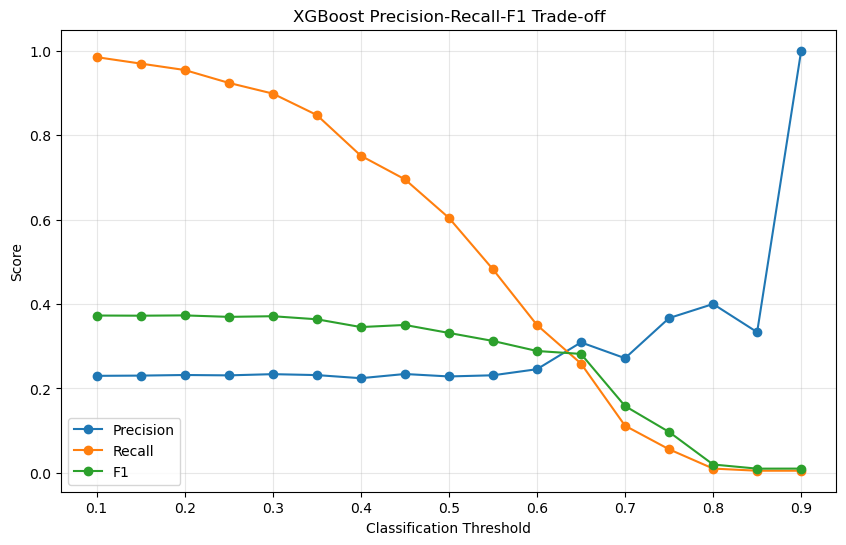

In [85]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost Precision-Recall-F1 Trade-off")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [86]:
# Find threshold with maximum F1
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best Threshold:")
print(round(best_row["Threshold"], 2))

print("\nPrecision:")
print(round(best_row["Precision"], 4))

print("\nRecall:")
print(round(best_row["Recall"], 4))

print("\nF1 Score:")
print(round(best_row["F1"], 4))

Best Threshold:
0.2

Precision:
0.2318

Recall:
0.9543

F1 Score:
0.373


In [87]:
best_threshold = best_row["Threshold"]

xgb_pred_tuned = (
    xgb_prob >= best_threshold
).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred_tuned,
        target_names=["Not Fraud", "Fraud"]
    )
)

Confusion Matrix:
[[180 623]
 [  9 188]]

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.95      0.22      0.36       803
       Fraud       0.23      0.95      0.37       197

    accuracy                           0.37      1000
   macro avg       0.59      0.59      0.37      1000
weighted avg       0.81      0.37      0.36      1000



In [88]:
print("Accuracy :", round(
    accuracy_score(y_test, xgb_pred_tuned), 4
))

print("Precision:", round(
    precision_score(y_test, xgb_pred_tuned), 4
))

print("Recall   :", round(
    recall_score(y_test, xgb_pred_tuned), 4
))

print("F1 Score :", round(
    f1_score(y_test, xgb_pred_tuned), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, xgb_prob), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, xgb_prob), 4
))

Accuracy : 0.368
Precision: 0.2318
Recall   : 0.9543
F1 Score : 0.373
ROC-AUC  : 0.6049
PR-AUC   : 0.2611


In [89]:
#Hyperparameter tuning + cross-validation: Stratified 5-Fold Cross-Validation

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    make_scorer,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score
)

import numpy as np

In [90]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation created.")

5-Fold Stratified Cross-Validation created.


In [91]:
rf_param_grid = {
    "classifier__n_estimators": [200, 300, 500, 700],
    "classifier__max_depth": [None, 5, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [
        "balanced",
        "balanced_subsample"
    ]
}

In [92]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,

    n_iter=30,

    scoring="f1",

    cv=cv,

    verbose=2,
    random_state=42,

    n_jobs=-1,

    return_train_score=False
)

In [93]:
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__class_weight': ['balanced', 'balanced_subsample'], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [94]:
print("Best Random Forest Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation F1:")
print(round(rf_search.best_score_, 4))

Best Random Forest Parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 5, 'classifier__class_weight': 'balanced_subsample'}

Best Cross-Validation F1:
0.371


In [95]:
best_rf = rf_search.best_estimator_

rf_tuned_pred = best_rf.predict(X_test)
rf_tuned_prob = best_rf.predict_proba(X_test)[:, 1]

In [96]:
print("=" * 60)
print("TUNED RANDOM FOREST")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_tuned_pred,
        target_names=["Not Fraud", "Fraud"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_tuned_pred))

print("\nMetrics:")

print("Accuracy :", round(
    accuracy_score(y_test, rf_tuned_pred), 4
))

print("Precision:", round(
    precision_score(y_test, rf_tuned_pred), 4
))

print("Recall   :", round(
    recall_score(y_test, rf_tuned_pred), 4
))

print("F1 Score :", round(
    f1_score(y_test, rf_tuned_pred), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, rf_tuned_prob), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, rf_tuned_prob), 4
))

TUNED RANDOM FOREST

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.89      0.34      0.50       803
       Fraud       0.24      0.83      0.37       197

    accuracy                           0.44      1000
   macro avg       0.57      0.59      0.43      1000
weighted avg       0.76      0.44      0.47      1000


Confusion Matrix:
[[276 527]
 [ 33 164]]

Metrics:
Accuracy : 0.44
Precision: 0.2373
Recall   : 0.8325
F1 Score : 0.3694
ROC-AUC  : 0.6028
PR-AUC   : 0.2417


In [97]:
xgb_param_grid = {
    "classifier__n_estimators": [
        200, 300, 500, 700
    ],

    "classifier__max_depth": [
        3, 4, 5, 6, 8
    ],

    "classifier__learning_rate": [
        0.01, 0.03, 0.05, 0.1
    ],

    "classifier__min_child_weight": [
        1, 3, 5, 7
    ],

    "classifier__subsample": [
        0.7, 0.8, 0.9, 1.0
    ],

    "classifier__colsample_bytree": [
        0.7, 0.8, 0.9, 1.0
    ],

    "classifier__gamma": [
        0, 0.1, 0.3, 0.5
    ],

    "classifier__reg_alpha": [
        0,
        0.01,
        0.1
    ],

    "classifier__reg_lambda": [
        1,
        2,
        5
    ],

    "classifier__scale_pos_weight": [
        2.5,
        3.0,
        3.5,
        4.09,
        4.5,
        5.0
    ]
}

In [99]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,

    param_distributions=xgb_param_grid,

    n_iter=40,

    scoring="f1",

    cv=cv,

    verbose=2,

    random_state=42,

    n_jobs=-1,

    return_train_score=False
)

In [100]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [3, 4, ...], ...}"
,n_iter,40
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [101]:
print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest Cross-Validation F1:")
print(round(xgb_search.best_score_, 4))

Best XGBoost Parameters:
{'classifier__subsample': 1.0, 'classifier__scale_pos_weight': 5.0, 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 7, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.9}

Best Cross-Validation F1:
0.37


In [102]:
best_xgb = xgb_search.best_estimator_

xgb_tuned_pred = best_xgb.predict(X_test)

xgb_tuned_prob = best_xgb.predict_proba(X_test)[:, 1]

In [103]:
print("=" * 60)
print("TUNED XGBOOST")
print("=" * 60)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        xgb_tuned_pred,
        target_names=["Not Fraud", "Fraud"]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        xgb_tuned_pred
    )
)

print("\nMetrics:")

print("Accuracy :", round(
    accuracy_score(y_test, xgb_tuned_pred), 4
))

print("Precision:", round(
    precision_score(y_test, xgb_tuned_pred), 4
))

print("Recall   :", round(
    recall_score(y_test, xgb_tuned_pred), 4
))

print("F1 Score :", round(
    f1_score(y_test, xgb_tuned_pred), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, xgb_tuned_prob), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, xgb_tuned_prob), 4
))

TUNED XGBOOST

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.97      0.21      0.34       803
       Fraud       0.23      0.97      0.37       197

    accuracy                           0.36      1000
   macro avg       0.60      0.59      0.36      1000
weighted avg       0.82      0.36      0.35      1000


Confusion Matrix:
[[168 635]
 [  6 191]]

Metrics:
Accuracy : 0.359
Precision: 0.2312
Recall   : 0.9695
F1 Score : 0.3734
ROC-AUC  : 0.6052
PR-AUC   : 0.2398


In [104]:
comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Feature-Engineered Random Forest",
        "Tuned Random Forest",
        "Original XGBoost",
        "Feature-Engineered XGBoost",
        "Tuned XGBoost"
    ],

    "Accuracy": [
        0.595,
        0.586,
        accuracy_score(y_test, rf_tuned_pred),
        0.800,
        0.520,
        accuracy_score(y_test, xgb_tuned_pred)
    ],

    "Precision": [
        0.2277,
        0.2308,
        precision_score(y_test, rf_tuned_pred),
        0.2857,
        0.2284,
        precision_score(y_test, xgb_tuned_pred)
    ],

    "Recall": [
        0.4416,
        0.4721,
        recall_score(y_test, rf_tuned_pred),
        0.0102,
        0.6041,
        recall_score(y_test, xgb_tuned_pred)
    ],

    "F1": [
        0.3005,
        0.3100,
        f1_score(y_test, rf_tuned_pred),
        0.0196,
        0.3315,
        f1_score(y_test, xgb_tuned_pred)
    ],

    "ROC_AUC": [
        0.6014,
        0.6116,
        roc_auc_score(y_test, rf_tuned_prob),
        0.6053,
        0.6049,
        roc_auc_score(y_test, xgb_tuned_prob)
    ],

    "PR_AUC": [
        0.2618,
        0.2663,
        average_precision_score(y_test, rf_tuned_prob),
        0.2656,
        0.2611,
        average_precision_score(y_test, xgb_tuned_prob)
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Original Random Forest,0.595,0.2277,0.4416,0.3005,0.6014,0.2618
1,Feature-Engineered Random Forest,0.586,0.2308,0.4721,0.3100,0.6116,0.2663
2,Tuned Random Forest,0.440,0.2373,0.8325,0.3694,0.6028,0.2417
3,Original XGBoost,0.800,0.2857,0.0102,0.0196,0.6053,0.2656
4,Feature-Engineered XGBoost,0.520,0.2284,0.6041,0.3315,0.6049,0.2611
5,Tuned XGBoost,0.359,0.2312,0.9695,0.3734,0.6052,0.2398


In [105]:
from sklearn.model_selection import RandomizedSearchCV

rf_pr_search = RandomizedSearchCV(
    estimator=rf_pipeline,

    param_distributions=rf_param_grid,

    n_iter=30,

    scoring="average_precision",

    cv=cv,

    verbose=2,

    random_state=42,

    n_jobs=-1,

    return_train_score=False
)

rf_pr_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__class_weight': ['balanced', 'balanced_subsample'], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,n_iter,30
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [106]:
print("Best RF Parameters:")
print(rf_pr_search.best_params_)

print("\nBest Cross-Validation PR-AUC:")
print(round(rf_pr_search.best_score_, 4))

Best RF Parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 5, 'classifier__class_weight': 'balanced_subsample'}

Best Cross-Validation PR-AUC:
0.2388


In [107]:
best_rf_pr = rf_pr_search.best_estimator_

rf_pr_pred = best_rf_pr.predict(X_test)
rf_pr_prob = best_rf_pr.predict_proba(X_test)[:, 1]

In [108]:
print("=" * 60)
print("PR-AUC OPTIMIZED RANDOM FOREST")
print("=" * 60)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_pr_pred,
        target_names=["Not Fraud", "Fraud"]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        rf_pr_pred
    )
)

print("\nMetrics:")

print("Accuracy :", round(
    accuracy_score(y_test, rf_pr_pred), 4
))

print("Precision:", round(
    precision_score(y_test, rf_pr_pred), 4
))

print("Recall   :", round(
    recall_score(y_test, rf_pr_pred), 4
))

print("F1 Score :", round(
    f1_score(y_test, rf_pr_pred), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, rf_pr_prob), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, rf_pr_prob), 4
))

PR-AUC OPTIMIZED RANDOM FOREST

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.90      0.34      0.49       803
       Fraud       0.24      0.85      0.37       197

    accuracy                           0.44      1000
   macro avg       0.57      0.59      0.43      1000
weighted avg       0.77      0.44      0.47      1000


Confusion Matrix:
[[270 533]
 [ 30 167]]

Metrics:
Accuracy : 0.437
Precision: 0.2386
Recall   : 0.8477
F1 Score : 0.3724
ROC-AUC  : 0.5996
PR-AUC   : 0.241


In [109]:
xgb_pr_search = RandomizedSearchCV(
    estimator=xgb_pipeline,

    param_distributions=xgb_param_grid,

    n_iter=40,

    scoring="average_precision",

    cv=cv,

    verbose=2,

    random_state=42,

    n_jobs=-1,

    return_train_score=False
)

xgb_pr_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [3, 4, ...], ...}"
,n_iter,40
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [110]:
print("Best XGBoost Parameters:")
print(xgb_pr_search.best_params_)

print("\nBest Cross-Validation PR-AUC:")
print(round(xgb_pr_search.best_score_, 4))

Best XGBoost Parameters:
{'classifier__subsample': 1.0, 'classifier__scale_pos_weight': 5.0, 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 7, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.9}

Best Cross-Validation PR-AUC:
0.2438


In [111]:
best_xgb_pr = xgb_pr_search.best_estimator_

xgb_pr_pred = best_xgb_pr.predict(X_test)
xgb_pr_prob = best_xgb_pr.predict_proba(X_test)[:, 1]

In [112]:
print("=" * 60)
print("PR-AUC OPTIMIZED XGBOOST")
print("=" * 60)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        xgb_pr_pred,
        target_names=["Not Fraud", "Fraud"]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        xgb_pr_pred
    )
)

print("\nMetrics:")

print("Accuracy :", round(
    accuracy_score(y_test, xgb_pr_pred), 4
))

print("Precision:", round(
    precision_score(y_test, xgb_pr_pred), 4
))

print("Recall   :", round(
    recall_score(y_test, xgb_pr_pred), 4
))

print("F1 Score :", round(
    f1_score(y_test, xgb_pr_pred), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, xgb_pr_prob), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, xgb_pr_prob), 4
))

PR-AUC OPTIMIZED XGBOOST

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.97      0.21      0.34       803
       Fraud       0.23      0.97      0.37       197

    accuracy                           0.36      1000
   macro avg       0.60      0.59      0.36      1000
weighted avg       0.82      0.36      0.35      1000


Confusion Matrix:
[[168 635]
 [  6 191]]

Metrics:
Accuracy : 0.359
Precision: 0.2312
Recall   : 0.9695
F1 Score : 0.3734
ROC-AUC  : 0.6052
PR-AUC   : 0.2398


In [113]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    pred = (rf_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.377,0.2297,0.9188,0.3675
1,0.15,0.403,0.2326,0.8832,0.3683
2,0.20,0.418,0.2359,0.8731,0.3715
3,0.25,0.427,0.2367,0.8579,0.3710
4,0.30,0.452,0.2392,0.8173,0.3701
5,0.35,0.483,0.2386,0.7411,0.3609
6,0.40,0.511,0.2355,0.6599,0.3471
7,0.45,0.541,0.2327,0.5787,0.3319
8,0.50,0.586,0.2308,0.4721,0.3100
9,0.55,0.661,0.2585,0.3858,0.3096


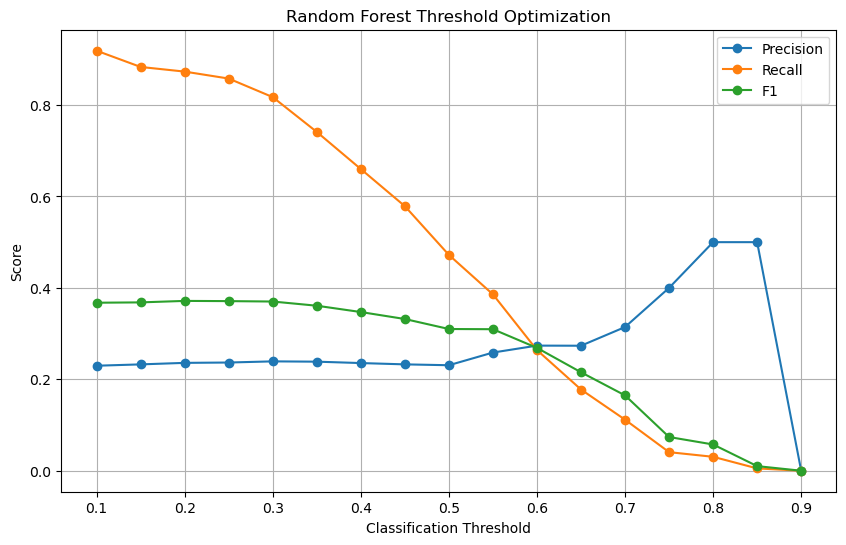

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Random Forest Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

In [115]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best Threshold:")
print(best_threshold_row)

Best Threshold:
Threshold    0.200000
Accuracy     0.418000
Precision    0.235940
Recall       0.873096
F1           0.371490
Name: 2, dtype: float64


In [116]:
best_threshold = best_threshold_row["Threshold"]

In [117]:
final_rf_pred = (
    rf_prob >= best_threshold
).astype(int)

In [118]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    final_rf_pred
)

print("Best Threshold:", best_threshold)
print("\nConfusion Matrix:")
print(cm)

Best Threshold: 0.20000000000000004

Confusion Matrix:
[[246 557]
 [ 25 172]]


In [119]:
print(
    classification_report(
        y_test,
        final_rf_pred,
        target_names=["Not Fraud", "Fraud"]
    )
)

              precision    recall  f1-score   support

   Not Fraud       0.91      0.31      0.46       803
       Fraud       0.24      0.87      0.37       197

    accuracy                           0.42      1000
   macro avg       0.57      0.59      0.41      1000
weighted avg       0.78      0.42      0.44      1000



In [120]:
df["Vehicle_Type_Dimension"] = (
    df["Vehicle_Type"].astype(str)
    + "_"
    + df["Vehicle_Dimensions"].astype(str)
)

In [121]:
df["Vehicle_Type_Lane"] = (
    df["Vehicle_Type"].astype(str)
    + "_"
    + df["Lane_Type"].astype(str)
)

In [122]:
df["Dimension_Lane"] = (
    df["Vehicle_Dimensions"].astype(str)
    + "_"
    + df["Lane_Type"].astype(str)
)

In [123]:
df["Vehicle_TollBooth"] = (
    df["Vehicle_Type"].astype(str)
    + "_"
    + df["TollBoothID"].astype(str)
)

In [124]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

df_ml = df.copy()

# 1. Vehicle Type × Vehicle Dimensions
df_ml["Vehicle_Type_Dimension"] = (
    df_ml["Vehicle_Type"].astype(str)
    + "_"
    + df_ml["Vehicle_Dimensions"].astype(str)
)

# 2. Vehicle Type × Lane Type
df_ml["Vehicle_Type_Lane"] = (
    df_ml["Vehicle_Type"].astype(str)
    + "_"
    + df_ml["Lane_Type"].astype(str)
)

# 3. Vehicle Dimensions × Lane Type
df_ml["Dimension_Lane"] = (
    df_ml["Vehicle_Dimensions"].astype(str)
    + "_"
    + df_ml["Lane_Type"].astype(str)
)

print("New features created successfully.")

print(df_ml[
    [
        "Vehicle_Type",
        "Vehicle_Dimensions",
        "Lane_Type",
        "Vehicle_Type_Dimension",
        "Vehicle_Type_Lane",
        "Dimension_Lane"
    ]
].head())

New features created successfully.
  Vehicle_Type Vehicle_Dimensions Lane_Type Vehicle_Type_Dimension  \
0          Bus              Large   Express              Bus_Large   
1          Car              Small   Regular              Car_Small   
2   Motorcycle              Small   Regular       Motorcycle_Small   
3        Truck              Large   Regular            Truck_Large   
4          Van             Medium   Express             Van_Medium   

    Vehicle_Type_Lane  Dimension_Lane  
0         Bus_Express   Large_Express  
1         Car_Regular   Small_Regular  
2  Motorcycle_Regular   Small_Regular  
3       Truck_Regular   Large_Regular  
4         Van_Express  Medium_Express  


In [125]:
# ==========================================
# FEATURES AND TARGET
# ==========================================

features = [
    "Vehicle_Type",
    "Lane_Type",
    "Vehicle_Dimensions",
    "TollBoothID",
    "Vehicle_Speed",

    # New interaction features
    "Vehicle_Type_Dimension",
    "Vehicle_Type_Lane",
    "Dimension_Lane"
]

X = df_ml[features].copy()
y = df_ml["Fraud_Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

X shape: (5000, 8)
y shape: (5000,)

Target distribution:
Fraud_Label
0    4017
1     983
Name: count, dtype: int64

Target percentage:
Fraud_Label
0    80.34
1    19.66
Name: proportion, dtype: float64


In [126]:
# ==========================================
# FEATURE TYPES
# ==========================================

categorical_features = [
    "Vehicle_Type",
    "Lane_Type",
    "Vehicle_Dimensions",
    "TollBoothID",
    "Vehicle_Type_Dimension",
    "Vehicle_Type_Lane",
    "Dimension_Lane"
]

numerical_features = [
    "Vehicle_Speed"
]

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (4000, 8)
Testing data : (1000, 8)


In [128]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [130]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    )
])

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [131]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("RANDOM FOREST — 3 INTERACTION FEATURES")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Not Fraud", "Fraud"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nMetrics:")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_prob), 4))
print("PR-AUC   :", round(average_precision_score(y_test, rf_prob), 4))

RANDOM FOREST — 3 INTERACTION FEATURES

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.82      0.63      0.71       803
       Fraud       0.23      0.44      0.30       197

    accuracy                           0.59      1000
   macro avg       0.52      0.54      0.51      1000
weighted avg       0.70      0.59      0.63      1000


Confusion Matrix:
[[508 295]
 [110  87]]

Metrics:
Accuracy : 0.595
Precision: 0.2277
Recall   : 0.4416
F1 Score : 0.3005
ROC-AUC  : 0.6015
PR-AUC   : 0.2606


In [132]:
from xgboost import XGBClassifier

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 4.089058524173028


In [133]:
xgb_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss"
        )
    )
])

xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [134]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("XGBOOST — 3 INTERACTION FEATURES")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Not Fraud", "Fraud"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nMetrics:")
print("Accuracy :", round(accuracy_score(y_test, xgb_pred), 4))
print("Precision:", round(precision_score(y_test, xgb_pred), 4))
print("Recall   :", round(recall_score(y_test, xgb_pred), 4))
print("F1 Score :", round(f1_score(y_test, xgb_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, xgb_prob), 4))
print("PR-AUC   :", round(average_precision_score(y_test, xgb_prob), 4))

XGBOOST — 3 INTERACTION FEATURES

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.84      0.51      0.64       803
       Fraud       0.24      0.61      0.34       197

    accuracy                           0.53      1000
   macro avg       0.54      0.56      0.49      1000
weighted avg       0.72      0.53      0.58      1000


Confusion Matrix:
[[410 393]
 [ 76 121]]

Metrics:
Accuracy : 0.531
Precision: 0.2354
Recall   : 0.6142
F1 Score : 0.3404
ROC-AUC  : 0.609
PR-AUC   : 0.2613


In [135]:
results_new = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],

    "PR-AUC": [
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, xgb_prob)
    ]
})

display(results_new.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.595,0.2277,0.4416,0.3005,0.6015,0.2606
1,XGBoost,0.531,0.2354,0.6142,0.3404,0.6090,0.2613


In [136]:

# ==========================================
# STACKING: RANDOM FOREST + XGBOOST
# ==========================================

from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier

# Fresh preprocessing object for each pipeline
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [137]:
# ==========================================
# BASE MODEL 1 — RANDOM FOREST
# ==========================================

rf_base = Pipeline([
    (
        "preprocessor",
        rf_preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    )
])


# ==========================================
# BASE MODEL 2 — XGBOOST
# ==========================================

xgb_base = Pipeline([
    (
        "preprocessor",
        xgb_preprocessor
    ),
    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss"
        )
    )
])

In [138]:
# ==========================================
# STACKING MODEL
# ==========================================

stacking_model = StackingClassifier(
    estimators=[
        ("random_forest", rf_base),
        ("xgboost", xgb_base)
    ],

    # Meta learner
    final_estimator=RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    # 5-fold cross-validation
    cv=5,

    # Use probability outputs from RF and XGBoost
    stack_method="predict_proba",

    n_jobs=-1
)

print("Stacking model created successfully.")

Stacking model created successfully.


In [139]:
# ==========================================
# TRAIN STACKING MODEL
# ==========================================

stacking_model.fit(
    X_train,
    y_train
)

print("Stacking model training completed.")

Stacking model training completed.


In [140]:
# ==========================================
# STACKING PREDICTIONS
# ==========================================

stack_pred = stacking_model.predict(X_test)

stack_prob = stacking_model.predict_proba(
    X_test
)[:, 1]

In [141]:
# ==========================================
# STACKING EVALUATION
# ==========================================

print("=" * 70)
print("STACKING — RANDOM FOREST + XGBOOST")
print("=" * 70)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        stack_pred,
        target_names=["Not Fraud", "Fraud"]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        stack_pred
    )
)

print("\nMetrics:")

print(
    "Accuracy :",
    round(accuracy_score(y_test, stack_pred), 4)
)

print(
    "Precision:",
    round(precision_score(y_test, stack_pred), 4)
)

print(
    "Recall   :",
    round(recall_score(y_test, stack_pred), 4)
)

print(
    "F1 Score :",
    round(f1_score(y_test, stack_pred), 4)
)

print(
    "ROC-AUC  :",
    round(roc_auc_score(y_test, stack_prob), 4)
)

print(
    "PR-AUC   :",
    round(average_precision_score(y_test, stack_prob), 4)
)

STACKING — RANDOM FOREST + XGBOOST

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.86      0.46      0.60       803
       Fraud       0.24      0.69      0.35       197

    accuracy                           0.50      1000
   macro avg       0.55      0.57      0.47      1000
weighted avg       0.73      0.50      0.55      1000


Confusion Matrix:
[[368 435]
 [ 62 135]]

Metrics:
Accuracy : 0.503
Precision: 0.2368
Recall   : 0.6853
F1 Score : 0.352
ROC-AUC  : 0.5934
PR-AUC   : 0.2429


In [142]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "XGBoost Benchmark",
        "Stacking RF + XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, stack_pred)
    ],

    "Precision": [
        precision_score(y_test, xgb_pred),
        precision_score(y_test, stack_pred)
    ],

    "Recall": [
        recall_score(y_test, xgb_pred),
        recall_score(y_test, stack_pred)
    ],

    "F1": [
        f1_score(y_test, xgb_pred),
        f1_score(y_test, stack_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, stack_prob)
    ],

    "PR-AUC": [
        average_precision_score(y_test, xgb_prob),
        average_precision_score(y_test, stack_prob)
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost Benchmark,0.531,0.2354,0.6142,0.3404,0.6090,0.2613
1,Stacking RF + XGBoost,0.503,0.2368,0.6853,0.3520,0.5934,0.2429
